In [1]:
import os, cv2, torch, random, shutil, warnings
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, f1_score,
                              classification_report, roc_auc_score)
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models

In [2]:
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# ── Paths (same as RCNN notebook) ──────────────────────────────────────────
DATASET_PATH    = "/kaggle/input/datasets/abdullahelafifi/main-data/Main data"
ANNOTATIONS_DIR = os.path.join(DATASET_PATH, "Annotations")
IMAGES_DIR      = os.path.join(DATASET_PATH, "JPEGImages")
SPLITS_DIR      = os.path.join(DATASET_PATH, "ImageSets/Main")

CROP_DIR        = "/kaggle/working/densenet_crops"
SAVE_DIR        = "/kaggle/working/densenet_models"
os.makedirs(CROP_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# ── Preprocessing constants (IDENTICAL to RCNN) ────────────────────────────
CLAHE_CLIP     = 2.0
CLAHE_GRID     = (8, 8)
CROP_MARGIN    = 30          # px added around GT bbox before crop
RESIZE_SIZE    = 224         # DenseNet input

LABEL_MAP      = {"0": 0, "1": 1}   # 0 = benign, 1 = malignant
CLASS_NAMES    = ["benign", "malignant"]

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
# ── Preprocessing constants (IDENTICAL to RCNN) ────────────────────────────

def preprocess_image(img_bgr):
    # ── Step 1: CLAHE on L channel ─────────────────────────────────────
    lab       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b   = cv2.split(lab)
    clahe     = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_clahe   = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge([l_clahe, a, b]), cv2.COLOR_LAB2BGR)

    # ── Step 2: Mild unsharp masking (edge enhancement) ────────────────
    blurred   = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=2)
    sharpened = cv2.addWeighted(img_clahe, 1.3, blurred, -0.3, 0)

    return sharpened
    
def parse_xml(xml_path):
    tree  = ET.parse(xml_path)
    root  = tree.getroot()
    items = []
    for obj in root.findall("object"):
        cls   = LABEL_MAP.get(obj.find("name").text.strip(), -1)
        xmin  = int(obj.find("bndbox/xmin").text)
        ymin  = int(obj.find("bndbox/ymin").text)
        xmax  = int(obj.find("bndbox/xmax").text)
        ymax  = int(obj.find("bndbox/ymax").text)
        if cls != -1 and xmax > xmin and ymax > ymin:
            items.append((cls, xmin, ymin, xmax, ymax))
    return items

def crop_and_save(img_ids, split_name):
    records = []
    for img_id in tqdm(img_ids, desc=f"Cropping [{split_name}]"):
        xml_path = os.path.join(ANNOTATIONS_DIR, img_id + ".xml")
        img_path = os.path.join(IMAGES_DIR,      img_id + ".jpg")

        if not os.path.exists(xml_path) or not os.path.exists(img_path):
            continue

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue

        img_bgr   = preprocess_image(img_bgr)           
        H, W      = img_bgr.shape[:2]

        for idx, (cls, xmin, ymin, xmax, ymax) in enumerate(parse_xml(xml_path)):
            # Add margin (same strategy as RCNN crop pipeline)
            x1 = max(0, xmin - CROP_MARGIN)
            y1 = max(0, ymin - CROP_MARGIN)
            x2 = min(W, xmax + CROP_MARGIN)
            y2 = min(H, ymax + CROP_MARGIN)

            crop = img_bgr[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # Save with original ID so it maps back to the txt split files
            save_name = f"{img_id}_{idx}.jpg"
            save_path = os.path.join(CROP_DIR, save_name)
            cv2.imwrite(save_path, crop)

            records.append({
                "img_id"   : img_id,
                "filename" : save_name,
                "label"    : cls,
                "split"    : split_name,
                "x1": x1, "y1": y1, "x2": x2, "y2": y2
            })
    return records


In [6]:
# ── Load split IDs ──────────────────────────────────────────────────────────
def read_ids(fname):
    with open(os.path.join(SPLITS_DIR, fname)) as f:
        return f.read().splitlines()

train_ids    = read_ids("train.txt")
val_ids      = read_ids("val.txt")
test_ids     = read_ids("test.txt")
trainval_ids = train_ids + val_ids

In [7]:
# ── Run cropping ────────────────────────────────────────────────────────────
all_records = []
all_records += crop_and_save(trainval_ids, "trainval")
all_records += crop_and_save(test_ids,     "test")

df = pd.DataFrame(all_records)
df.to_csv("/kaggle/working/crop_index.csv", index=False)
print(f"\nTotal crops saved: {len(df)}")

Cropping [test]: 100%|██████████| 1000/1000 [00:24<00:00, 41.67it/s]



Total crops saved: 5000


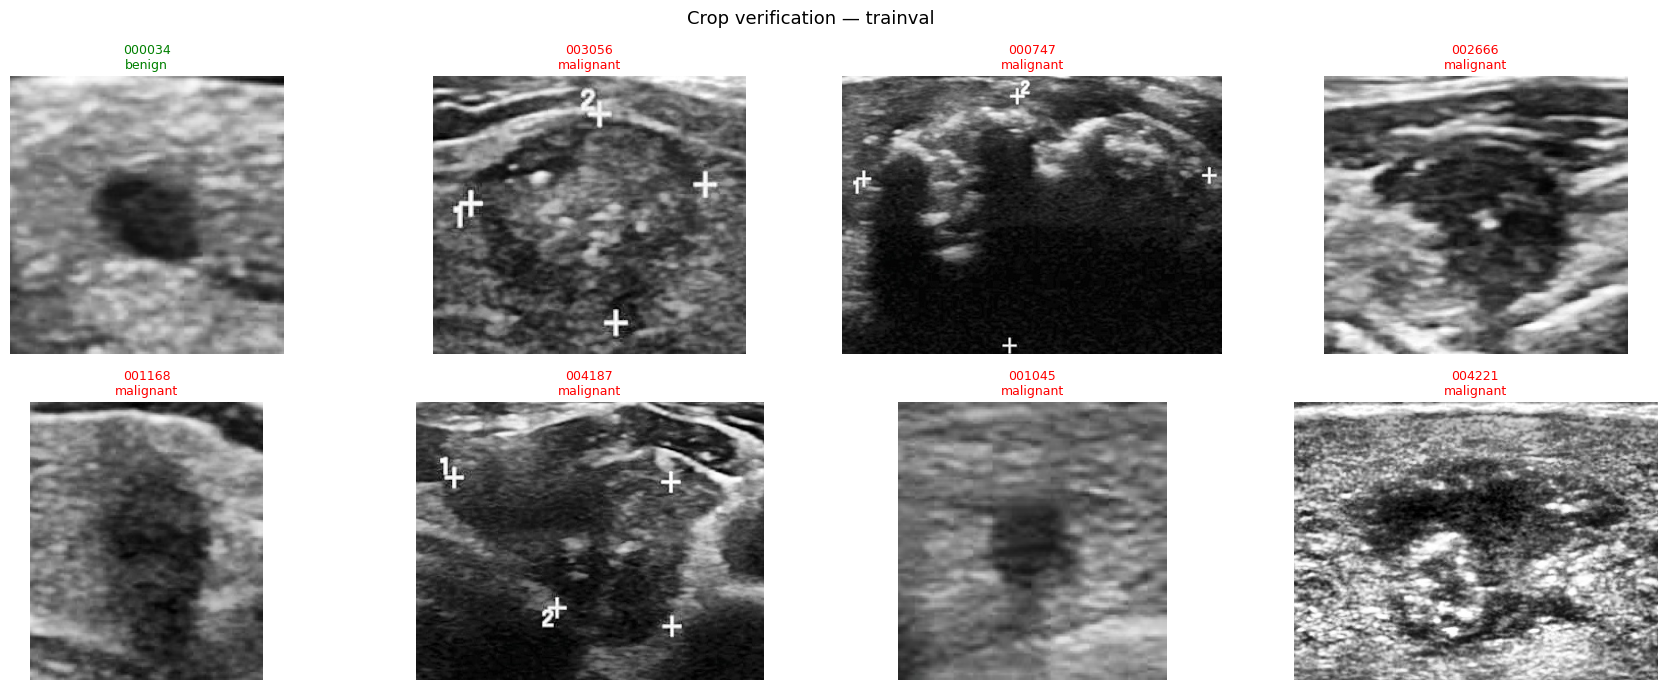

In [8]:
def show_crops(df, n=8, split="trainval"):
    sample = df[df["split"] == split].sample(n, random_state=42)
    fig, axes = plt.subplots(2, n//2, figsize=(18, 7))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(os.path.join(CROP_DIR, row["filename"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(
            f"{row['img_id']}\n{CLASS_NAMES[row['label']]}",
            fontsize=9, color="red" if row["label"] == 1 else "green"
        )
        axes[i].axis("off")
    plt.suptitle(f"Crop verification — {split}", fontsize=13)
    plt.tight_layout()
    plt.show()

show_crops(df, n=8)

In [9]:
def print_counts(df):
    tv = df[df["split"] == "trainval"]
    te = df[df["split"] == "test"]
    print("=" * 45)
    print(f"  Trainval total : {len(tv)}")
    print(f"    benign       : {(tv['label']==0).sum()}")
    print(f"    malignant    : {(tv['label']==1).sum()}")
    print(f"  Test total     : {len(te)}")
    print(f"    benign       : {(te['label']==0).sum()}")
    print(f"    malignant    : {(te['label']==1).sum()}")
    print("=" * 45)

print_counts(df)

  Trainval total : 4000
    benign       : 1157
    malignant    : 2843
  Test total     : 1000
    benign       : 269
    malignant    : 731


In [10]:
# ── Transforms ─────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# WITH THIS — moderate, stable augmentation:
train_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [11]:
# ── Dataset ─────────────────────────────────────────────────────────────────
class ThyroidCropDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records   = records.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row  = self.records.iloc[idx]
        path = os.path.join(CROP_DIR, row["filename"])
        img  = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

In [12]:
# ── Class weights for imbalance (same philosophy as RCNN) ──────────────────
def compute_class_weights(labels):
    counts  = np.bincount(labels)
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(counts)
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

In [13]:
tv_df = df[df["split"] == "trainval"].copy()
te_df = df[df["split"] == "test"].copy()

labels_tv = tv_df["label"].values
cw        = compute_class_weights(labels_tv)

print("\n===== Final Dataset Summary =====")
print(f"  Trainval crops : {len(tv_df)}")
print(f"  Test crops     : {len(te_df)}")
print(f"  Class weights  : benign={cw[0]:.3f}, malignant={cw[1]:.3f}")
print(f"  Augmentation   : HFlip, VFlip, Rotation±10°, ColorJitter")
print(f"  Input size     : {RESIZE_SIZE}×{RESIZE_SIZE}")
print(f"  K-Folds        : 3 (StratifiedKFold on trainval)")
print("=================================")


===== Final Dataset Summary =====
  Trainval crops : 4000
  Test crops     : 1000
  Class weights  : benign=1.421, malignant=0.578
  Augmentation   : HFlip, VFlip, Rotation±10°, ColorJitter
  Input size     : 224×224
  K-Folds        : 3 (StratifiedKFold on trainval)


In [14]:
def build_densenet(num_classes=2, dropout=0.5):  # dropout 0.4 → 0.5
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # Freeze ALL feature layers first
    for param in model.features.parameters():
        param.requires_grad = False

    # Unfreeze ONLY block 4 + final norm (was block 3+4 before)
    for name, param in model.features.named_parameters():
        if any(k in name for k in ["denseblock4", "norm5"]):
            param.requires_grad = True

    # Replace classifier
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params   : {total:,}")
    print(f"Trainable      : {trainable:,}  ({100*trainable/total:.1f}%)")
    return model.to(DEVICE)

In [15]:
# ── Training config ─────────────────────────────────────────────────────────
NUM_EPOCHS  = 20
LR          = 2e-4
WEIGHT_DECAY= 1e-4
BATCH_SIZE  = 32
K_FOLDS     = 3

In [16]:
def run_epoch(model, loader, criterion, optimizer=None, phase="train", epoch=1, num_epochs=1):
    is_train = (phase == "train")
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    # WITH THIS:
    pbar = tqdm(loader, desc=f"Epoch [{epoch:02d}/{num_epochs}] {phase.capitalize():5}",
                leave=False, dynamic_ncols=True, ncols=100,
                file=__import__('sys').stdout)

    with torch.set_grad_enabled(is_train):
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train and optimizer is not None:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            if is_train and optimizer is not None:
                loss.backward()
                optimizer.step()

            preds       = outputs.argmax(dim=1)
            correct     += (preds == labels).sum().item()
            total       += labels.size(0)
            total_loss  += loss.item() * labels.size(0)

            pbar.set_postfix({
                f"{phase}_loss": f"{total_loss/total:.4f}",
                "acc"          : f"{correct/total:.4f}"
            })

    return total_loss / total, correct / total

In [27]:
# ── K-Fold training ─────────────────────────────────────────────────────────
def train_kfold(tv_df):
    skf      = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    labels   = tv_df["label"].values
    fold_results = []

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(tv_df, labels), 1):
        print(f"\n{'='*55}")
        print(f"  FOLD {fold}/{K_FOLDS}")
        print(f"{'='*55}")

        tr_df = tv_df.iloc[tr_idx]
        vl_df = tv_df.iloc[vl_idx]

        tr_ds = ThyroidCropDataset(tr_df, transform=train_transform)
        vl_ds = ThyroidCropDataset(vl_df, transform=val_transform)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
        vl_ld = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

        model     = build_densenet()
        cw        = compute_class_weights(tr_df["label"].values)
        criterion = nn.CrossEntropyLoss(weight=cw,label_smoothing=0.05)

        # ── Optimizer: AdamW (better than SGD for fine-tuning) ─────────────
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR, weight_decay=WEIGHT_DECAY
        )
        # ── Scheduler: cosine warm restarts (same as RCNN) ─────────────────
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,mode='min',factor=0.5,patience=4, min_lr=5e-6 )
        
        best_macro_f1 = 0.0
        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []

        for epoch in range(1, NUM_EPOCHS + 1):
            tr_loss, tr_acc = run_epoch(model, tr_ld, criterion, optimizer, "train", epoch, NUM_EPOCHS)
            vl_loss, vl_acc = run_epoch(model, vl_ld, criterion, None, "val",   epoch, NUM_EPOCHS)
            scheduler.step(vl_loss)

            train_losses.append(tr_loss); val_losses.append(vl_loss)
            train_accs.append(tr_acc);   val_accs.append(vl_acc)

            flag = ""
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for imgs, labels in vl_ld:
                    imgs = imgs.to(DEVICE)
                    preds = model(imgs).argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())
            
            macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            
            flag = ""
            if macro_f1 > best_macro_f1:
                best_macro_f1 = macro_f1
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, f"best_densenet_fold{fold}.pth"))
                flag = " ✓ saved"

            current_lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  "
                  f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  "
                  f"MalF1: {macro_f1:.4f}  LR: {current_lr:.6f}{flag}")


        fold_results.append({
            "fold": fold,
            "train_losses": train_losses, "val_losses": val_losses,
            "train_accs"  : train_accs,   "val_accs"   : val_accs,
            "best_macro_f1": best_macro_f1
        })

    return fold_results


In [28]:
fold_results = train_kfold(tv_df)


  FOLD 1/3
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
  Epoch [01/20]  Train Loss: 0.5828  Acc: 0.7157  |  Val Loss: 0.5034  Acc: 0.7954  MalF1: 0.7681  LR: 0.000200 ✓ saved
  Epoch [02/20]  Train Loss: 0.4890  Acc: 0.7911  |  Val Loss: 0.4871  Acc: 0.7961  MalF1: 0.7764  LR: 0.000200 ✓ saved
  Epoch [03/20]  Train Loss: 0.4491  Acc: 0.8218  |  Val Loss: 0.4667  Acc: 0.8426  MalF1: 0.8106  LR: 0.000200 ✓ saved
  Epoch [04/20]  Train Loss: 0.4369  Acc: 0.8350  |  Val Loss: 0.4729  Acc: 0.8028  MalF1: 0.7810  LR: 0.000200
  Epoch [05/20]  Train Loss: 0.4089  Acc: 0.8533  |  Val Loss: 0.4996  Acc: 0.8178  MalF1: 0.7896  LR: 0.000200
  Epoch [06/20]  Train Loss: 0.3997  Acc: 0.8601  |  Val Loss: 0.4819  Acc: 0.8351  MalF1: 0.8053  LR: 0.000200
  Epoch [07/20]  Train Loss: 0.3997  Acc: 0.8447  |  Val Loss: 0.4784  Acc: 0.8328  MalF1: 0.8059  LR: 0.000200
  Epoch [08/20]  Train Loss: 0.3784  Acc: 0.8691  |  Val Loss: 0.4744  Acc: 0.8328  MalF1: 0.8030  LR: 0.000100
  Epo

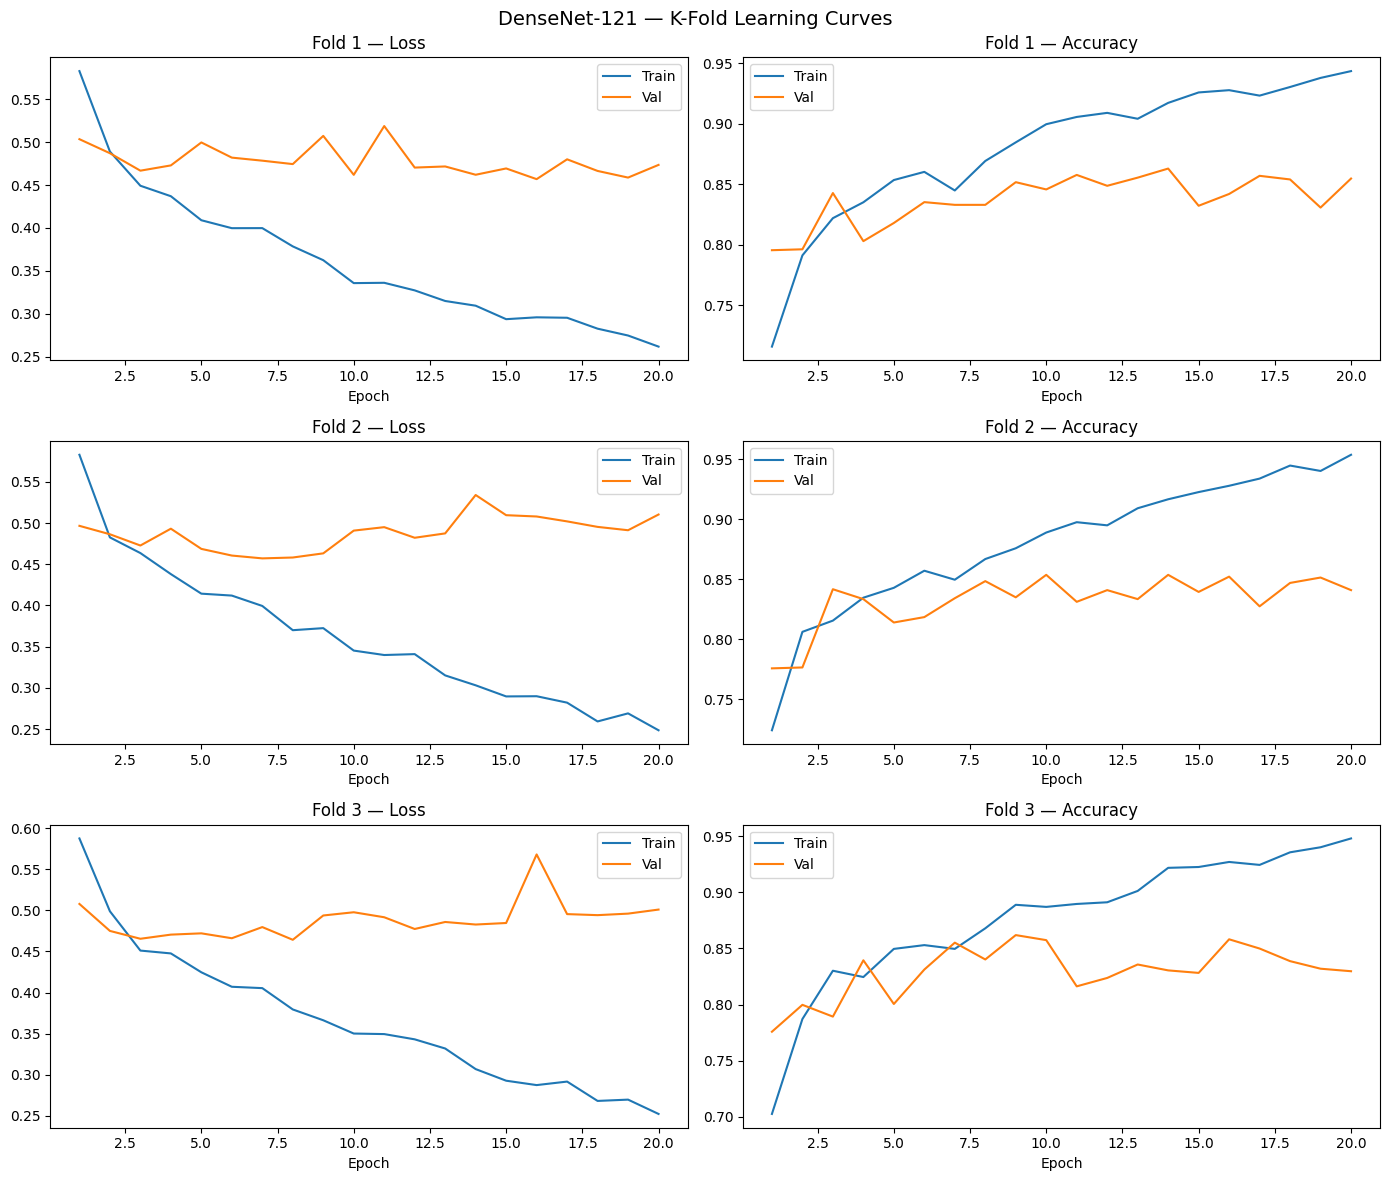

In [29]:
def plot_learning_curves(fold_results):
    fig, axes = plt.subplots(K_FOLDS, 2, figsize=(14, 4 * K_FOLDS))
    for i, res in enumerate(fold_results):
        ep = range(1, len(res["train_losses"]) + 1)
        axes[i, 0].plot(ep, res["train_losses"], label="Train")
        axes[i, 0].plot(ep, res["val_losses"],   label="Val")
        axes[i, 0].set_title(f"Fold {res['fold']} — Loss")
        axes[i, 0].legend(); axes[i, 0].set_xlabel("Epoch")

        axes[i, 1].plot(ep, res["train_accs"], label="Train")
        axes[i, 1].plot(ep, res["val_accs"],   label="Val")
        axes[i, 1].set_title(f"Fold {res['fold']} — Accuracy")
        axes[i, 1].legend(); axes[i, 1].set_xlabel("Epoch")

    plt.suptitle("DenseNet-121 — K-Fold Learning Curves", fontsize=14)
    plt.tight_layout()
    plt.savefig("/kaggle/working/densenet_learning_curves.png", dpi=150)
    plt.show()

plot_learning_curves(fold_results)

Using all 3 fold models for ensemble test evaluation
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)


Testing Ensemble: 100%|██████████| 32/32 [00:10<00:00,  3.05it/s]



===== DenseNet-121 Test Results =====
              precision    recall  f1-score   support

      benign       0.71      0.77      0.74       269
   malignant       0.91      0.89      0.90       731

    accuracy                           0.85      1000
   macro avg       0.81      0.83      0.82      1000
weighted avg       0.86      0.85      0.86      1000

F1 (macro)  : 0.8200
ROC-AUC     : 0.9137


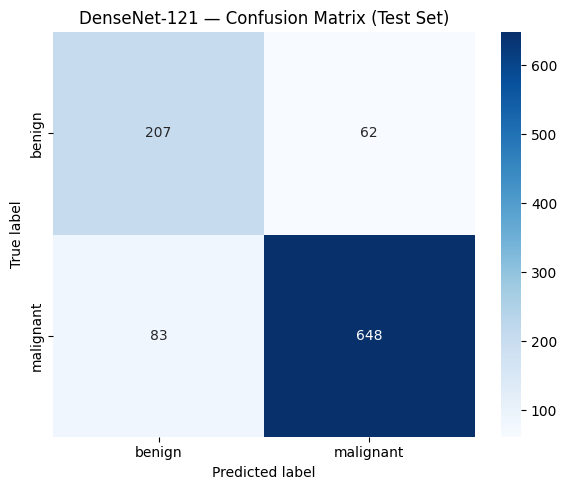

In [32]:
def evaluate_test_ensemble(te_df, malignant_threshold=0.35):
    # ---- load all 3 fold models ----
    fold_paths = [
        os.path.join(SAVE_DIR, "best_densenet_fold1.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold2.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold3.pth"),
    ]

    models = []
    for path in fold_paths:
        model = build_densenet()
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models.append(model)

    # ---- test dataset ----
    te_ds = ThyroidCropDataset(te_df, transform=val_transform)
    te_ld = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(te_ld, desc="Testing Ensemble"):
            imgs = imgs.to(DEVICE)

            prob_sum = None

            for model in models:
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)

                if prob_sum is None:
                    prob_sum = probs
                else:
                    prob_sum += probs

            avg_probs = prob_sum / len(models)

            malignant_prob = avg_probs[:, 1]
            preds = (malignant_prob >= malignant_threshold).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(avg_probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


print("Using all 3 fold models for ensemble test evaluation")
y_true, y_pred, y_prob = evaluate_test_ensemble(te_df, malignant_threshold=0.5)
# ── Metrics ─────────────────────────────────────────────────────────────────
print("\n===== DenseNet-121 Test Results =====")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"F1 (macro)  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob[:, 1]):.4f}")

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("DenseNet-121 — Confusion Matrix (Test Set)")
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("/kaggle/working/densenet_confusion_matrix.png", dpi=150)
plt.show()

Using all 3 fold models for ensemble test evaluation
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)


Testing Ensemble: 100%|██████████| 32/32 [00:10<00:00,  2.94it/s]



===== DenseNet-121 Test Results =====
              precision    recall  f1-score   support

      benign       0.81      0.68      0.74       269
   malignant       0.89      0.94      0.91       731

    accuracy                           0.87      1000
   macro avg       0.85      0.81      0.83      1000
weighted avg       0.87      0.87      0.87      1000

F1 (macro)  : 0.8253
ROC-AUC     : 0.9137


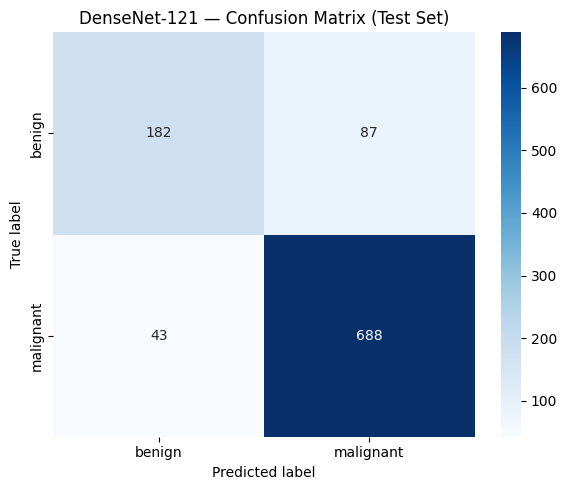

In [33]:
def evaluate_test_ensemble(te_df, malignant_threshold=0.35):
    # ---- load all 3 fold models ----
    fold_paths = [
        os.path.join(SAVE_DIR, "best_densenet_fold1.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold2.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold3.pth"),
    ]

    models = []
    for path in fold_paths:
        model = build_densenet()
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models.append(model)

    # ---- test dataset ----
    te_ds = ThyroidCropDataset(te_df, transform=val_transform)
    te_ld = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(te_ld, desc="Testing Ensemble"):
            imgs = imgs.to(DEVICE)

            prob_sum = None

            for model in models:
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)

                if prob_sum is None:
                    prob_sum = probs
                else:
                    prob_sum += probs

            avg_probs = prob_sum / len(models)

            malignant_prob = avg_probs[:, 1]
            preds = (malignant_prob >= malignant_threshold).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(avg_probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


print("Using all 3 fold models for ensemble test evaluation")
y_true, y_pred, y_prob = evaluate_test_ensemble(te_df, malignant_threshold=0.35)
# ── Metrics ─────────────────────────────────────────────────────────────────
print("\n===== DenseNet-121 Test Results =====")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"F1 (macro)  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob[:, 1]):.4f}")

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("DenseNet-121 — Confusion Matrix (Test Set)")
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("/kaggle/working/densenet_confusion_matrix.png", dpi=150)
plt.show()

Using all 3 fold models for ensemble test evaluation
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)


Testing Ensemble: 100%|██████████| 32/32 [00:10<00:00,  3.02it/s]



===== DenseNet-121 Test Results =====
              precision    recall  f1-score   support

      benign       0.68      0.80      0.73       269
   malignant       0.92      0.86      0.89       731

    accuracy                           0.84      1000
   macro avg       0.80      0.83      0.81      1000
weighted avg       0.85      0.84      0.85      1000

F1 (macro)  : 0.8103
ROC-AUC     : 0.9137


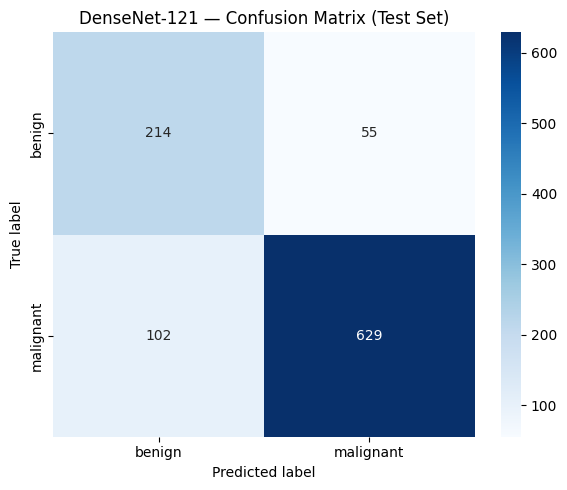

In [34]:
def evaluate_test_ensemble(te_df, malignant_threshold=0.35):
    # ---- load all 3 fold models ----
    fold_paths = [
        os.path.join(SAVE_DIR, "best_densenet_fold1.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold2.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold3.pth"),
    ]

    models = []
    for path in fold_paths:
        model = build_densenet()
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models.append(model)

    # ---- test dataset ----
    te_ds = ThyroidCropDataset(te_df, transform=val_transform)
    te_ld = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(te_ld, desc="Testing Ensemble"):
            imgs = imgs.to(DEVICE)

            prob_sum = None

            for model in models:
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)

                if prob_sum is None:
                    prob_sum = probs
                else:
                    prob_sum += probs

            avg_probs = prob_sum / len(models)

            malignant_prob = avg_probs[:, 1]
            preds = (malignant_prob >= malignant_threshold).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(avg_probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


print("Using all 3 fold models for ensemble test evaluation")
y_true, y_pred, y_prob = evaluate_test_ensemble(te_df, malignant_threshold=0.55)
# ── Metrics ─────────────────────────────────────────────────────────────────
print("\n===== DenseNet-121 Test Results =====")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"F1 (macro)  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob[:, 1]):.4f}")

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("DenseNet-121 — Confusion Matrix (Test Set)")
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("/kaggle/working/densenet_confusion_matrix.png", dpi=150)
plt.show()

Using all 3 fold models for ensemble test evaluation
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)


Testing Ensemble: 100%|██████████| 32/32 [00:10<00:00,  3.07it/s]



===== DenseNet-121 Test Results =====
              precision    recall  f1-score   support

      benign       0.75      0.74      0.74       269
   malignant       0.91      0.91      0.91       731

    accuracy                           0.86      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.86      0.86      0.86      1000

F1 (macro)  : 0.8256
ROC-AUC     : 0.9137


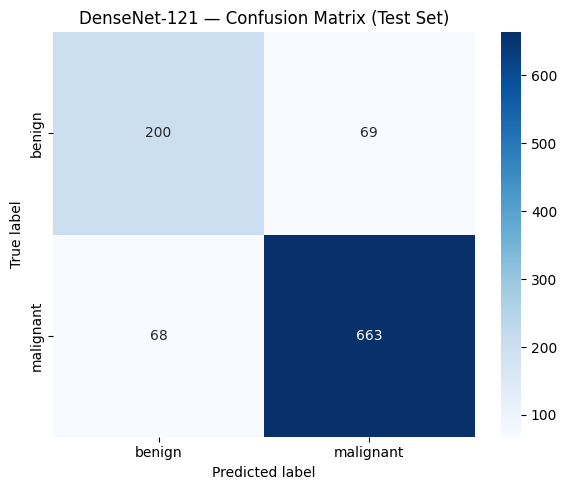

In [36]:
def evaluate_test_ensemble(te_df, malignant_threshold=0.35):
    # ---- load all 3 fold models ----
    fold_paths = [
        os.path.join(SAVE_DIR, "best_densenet_fold1.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold2.pth"),
        os.path.join(SAVE_DIR, "best_densenet_fold3.pth"),
    ]

    models = []
    for path in fold_paths:
        model = build_densenet()
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models.append(model)

    # ---- test dataset ----
    te_ds = ThyroidCropDataset(te_df, transform=val_transform)
    te_ld = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(te_ld, desc="Testing Ensemble"):
            imgs = imgs.to(DEVICE)

            prob_sum = None

            for model in models:
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)

                if prob_sum is None:
                    prob_sum = probs
                else:
                    prob_sum += probs

            avg_probs = prob_sum / len(models)

            malignant_prob = avg_probs[:, 1]
            preds = (malignant_prob >= malignant_threshold).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(avg_probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


print("Using all 3 fold models for ensemble test evaluation")
y_true, y_pred, y_prob = evaluate_test_ensemble(te_df, malignant_threshold=0.45)
# ── Metrics ─────────────────────────────────────────────────────────────────
print("\n===== DenseNet-121 Test Results =====")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"F1 (macro)  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob[:, 1]):.4f}")

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("DenseNet-121 — Confusion Matrix (Test Set)")
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("/kaggle/working/densenet_confusion_matrix.png", dpi=150)
plt.show()

Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)
Total params   : 6,955,906
Trainable      : 2,162,178  (31.1%)


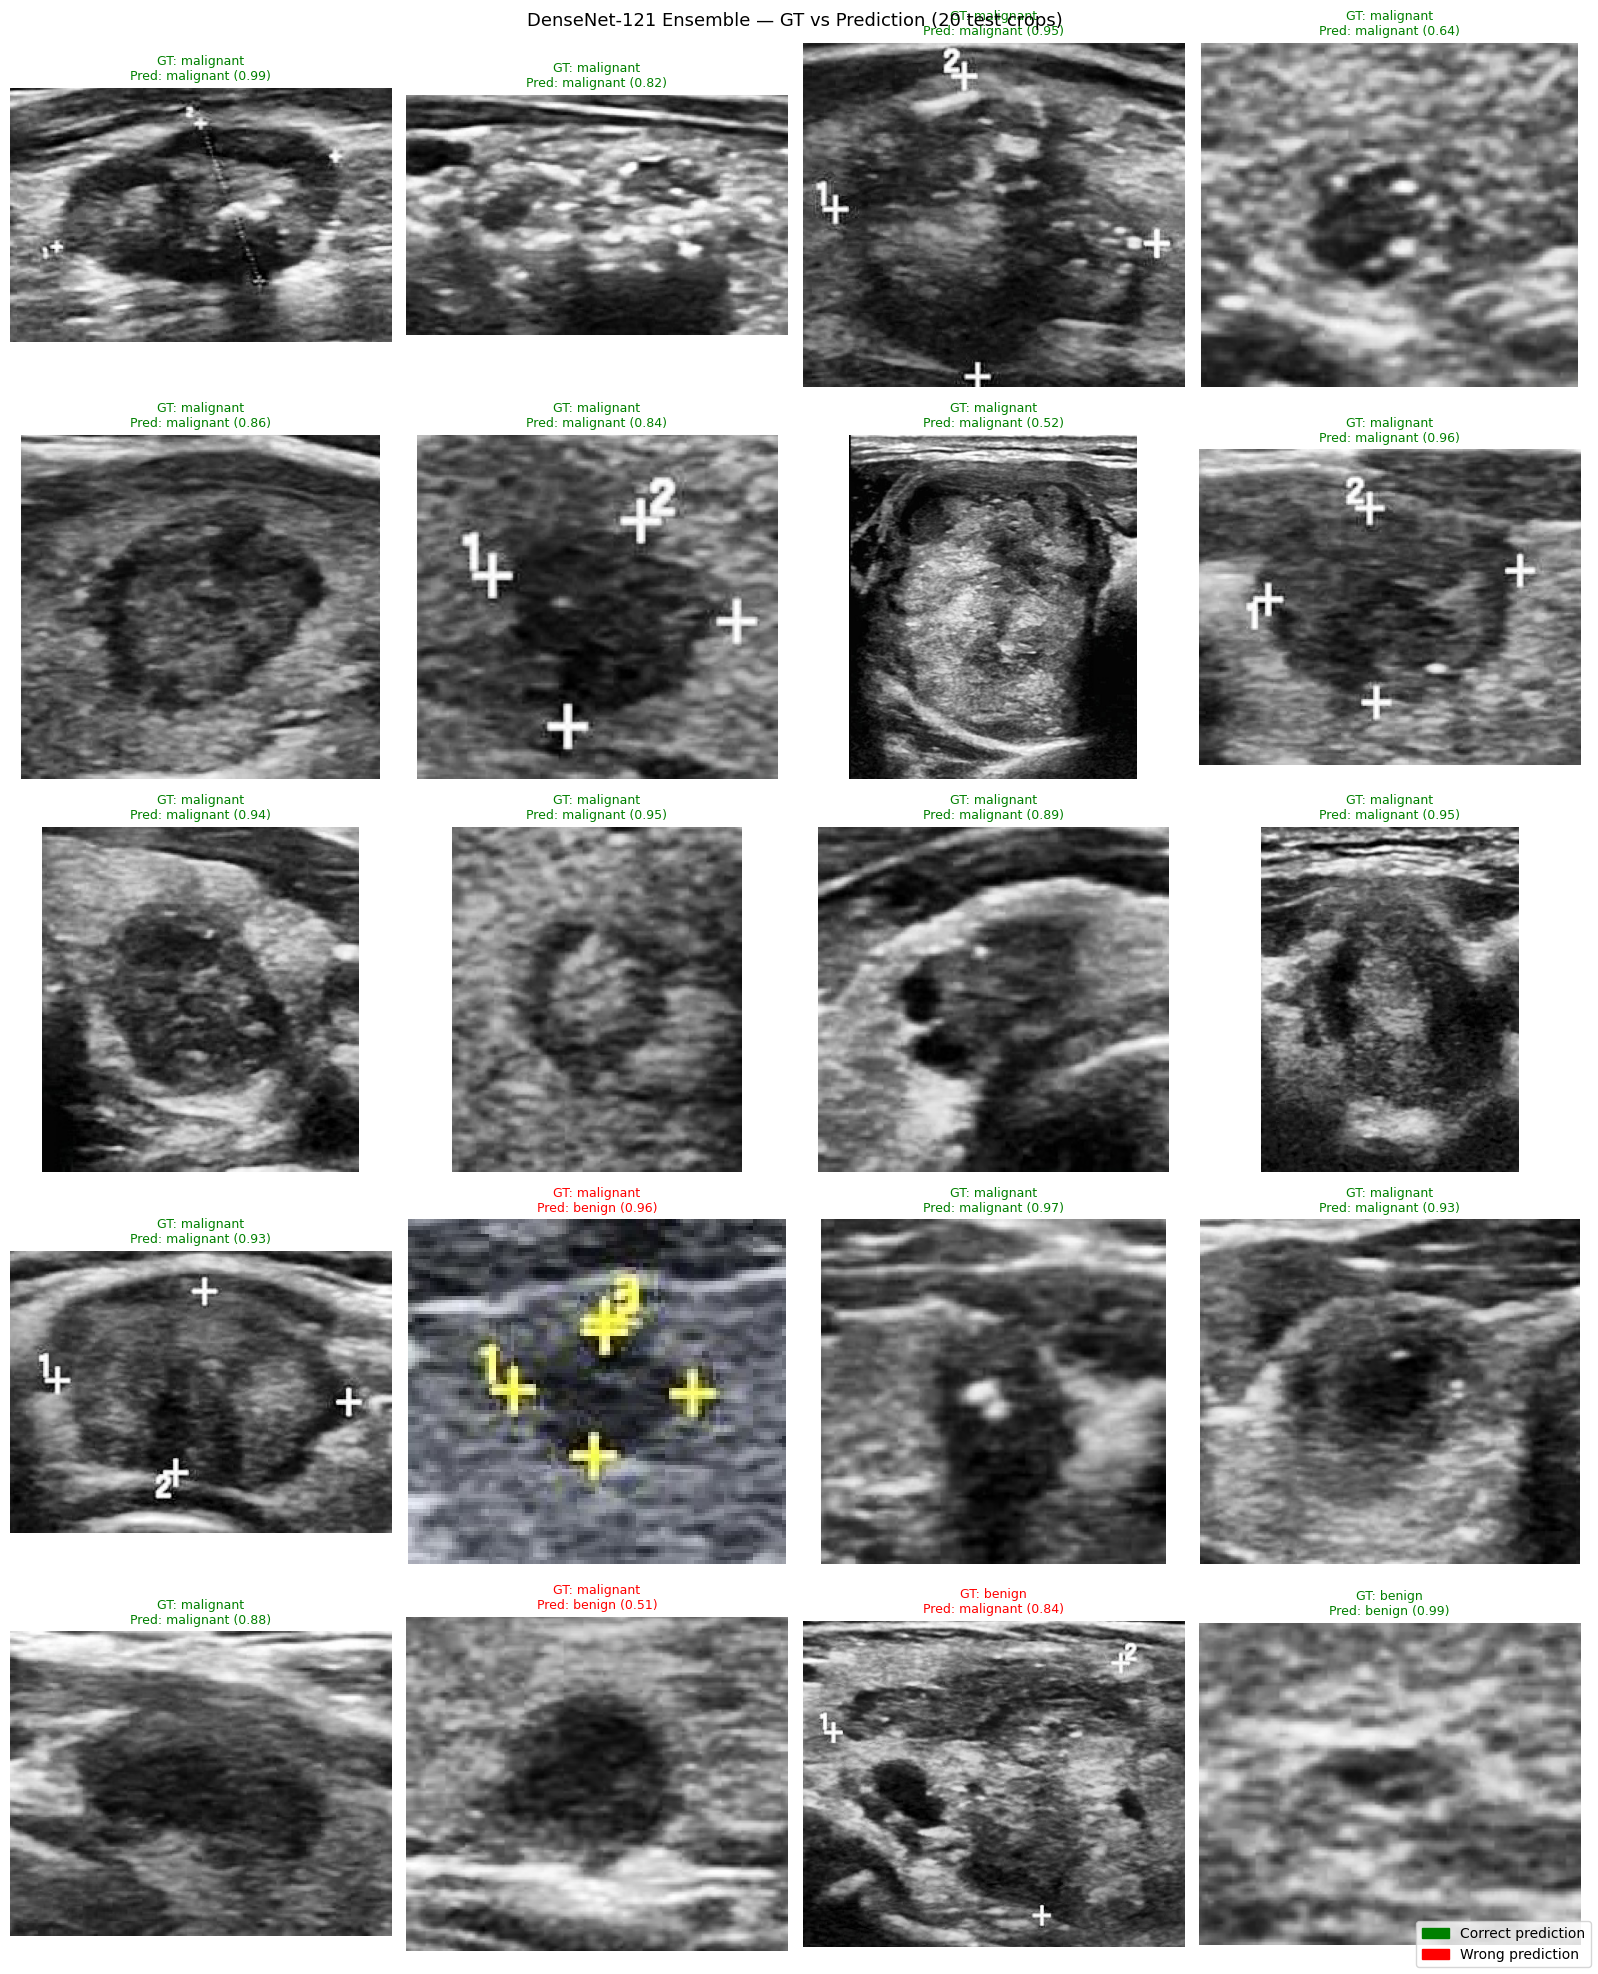

In [37]:
def show_gt_vs_pred_ensemble(all_models, te_df, n=20):
    sample = te_df.sample(n, random_state=7).reset_index(drop=True)
    cols   = 4
    rows   = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i, row in sample.iterrows():
        img_pil = Image.open(os.path.join(CROP_DIR, row["filename"])).convert("RGB")
        tensor  = val_transform(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            prob_sum = None
            for model in all_models:
                probs = torch.softmax(model(tensor), dim=1)
                prob_sum = probs if prob_sum is None else prob_sum + probs
            avg_probs = prob_sum / len(all_models)
            pred      = avg_probs.argmax(dim=1).item()
            conf      = avg_probs[0, pred].item()

        gt_name   = CLASS_NAMES[int(row["label"])]
        pred_name = CLASS_NAMES[pred]
        correct   = (pred == int(row["label"]))
        color     = "green" if correct else "red"

        axes[i].imshow(img_pil)
        axes[i].set_title(
            f"GT: {gt_name}\nPred: {pred_name} ({conf:.2f})",
            fontsize=9, color=color
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    gt_patch  = mpatches.Patch(color="green", label="Correct prediction")
    err_patch = mpatches.Patch(color="red",   label="Wrong prediction")
    fig.legend(handles=[gt_patch, err_patch], loc="lower right", fontsize=10)
    plt.suptitle("DenseNet-121 Ensemble — GT vs Prediction (20 test crops)", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/densenet_gt_vs_pred.png", dpi=150)
    plt.show()


# ── Load all 3 fold models for visualization ────────────────────────────────
fold_paths = [
    os.path.join(SAVE_DIR, "best_densenet_fold1.pth"),
    os.path.join(SAVE_DIR, "best_densenet_fold2.pth"),
    os.path.join(SAVE_DIR, "best_densenet_fold3.pth"),
]
viz_models = []
for path in fold_paths:
    m = build_densenet()
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    m.to(DEVICE)
    m.eval()
    viz_models.append(m)

show_gt_vs_pred_ensemble(viz_models, te_df, n=20)